# Active Learning for a Toy GPR model
In this lab, we use a simple GPR model to show case how to incorporate active learning in our model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Define a toy function to learn, and generate data from it

In [2]:
def target_function(x):
    return np.sin(3*x)

def noisy_function(x):
    return target_function(x) + 0.2*np.random.randn(*x.shape) # we add some gaussian noise

In [4]:
# We generate 200 noisy data, from which we want to learn the target function
n_data = 200
X = np.linspace(0, 2, n_data).reshape(-1,1)
y = noisy_function(X)
print(X.shape)

(200, 1)


In [5]:
# We generate 100 clean data as the test set
X_test = np.linspace(0, 2, 100).reshape(-1,1)
y_test = target_function(X_test)  # noiseless true function

### Visualize the data

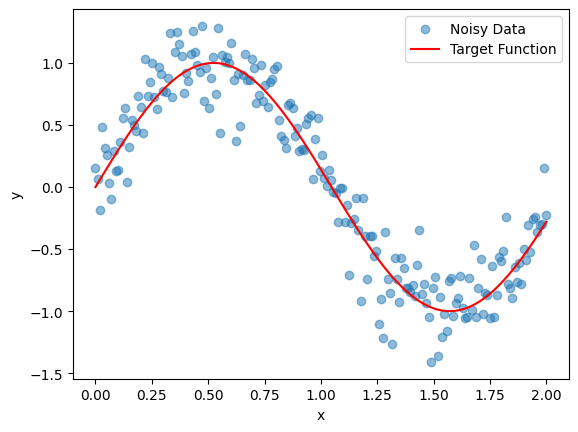

In [6]:
plt.scatter(X, y, alpha=0.5, label="Noisy Data")
plt.plot(X_test, y_test, 'r', label="Target Function")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

### Now let's divide the 200 noisy data into the labeled/unlabeld pools
We pretend that we do not know the $y$ value in the unlabeled pools.

In [7]:
idx = np.random.choice(n_data, 5, replace=False) # choose 5 indices
X_labeled, y_labeled = X[idx], y[idx] # only 5 labeled points

# remove the labeled points from the dataset to create the unlabeled pool
X_unlabeled = np.delete(X, idx, axis=0)
y_unlabeled = np.delete(y, idx, axis=0)

### Let's train a GPR on the labeled 5 indices
we add a white noise to the noisy dataset to the GPR kernel to learn the distribution of noise.
$$K_{\text{tot}} = K_{\text{RBF}} + \sigma_n^2 I$$
where $\sigma_n^2 I$ is the independent Gaussian noise with variance $\sigma_n^2$, and $I$ is an identity matrix.

In [8]:
kernel = 1.0*RBF(length_scale=0.3) + WhiteKernel(noise_level=0.1)

In [9]:
# train GPR
gpr = GaussianProcessRegressor(kernel=kernel, random_state=0)
gpr.fit(X_labeled, y_labeled)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=0.3) + WhiteKernel(noise_level=0.1),
                         random_state=0)

### Evaluate the output

In [10]:
# Evaluate on test set
y_pred, y_std = gpr.predict(X_test, return_std=True)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 0.28
RMSE: 0.31


### Visualize the current approximation

Text(0, 0.5, 'y')

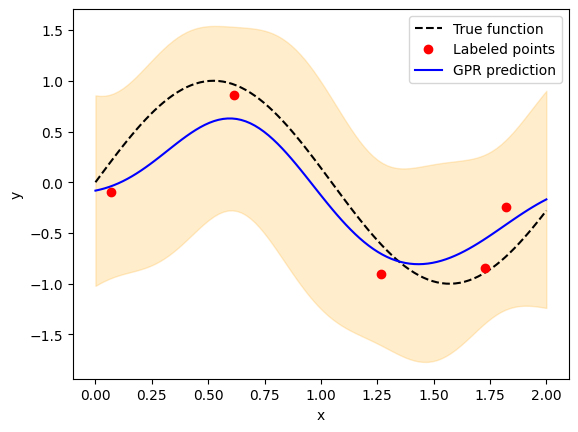

In [11]:
plt.fill_between(X_test.flatten(), y_pred-2*y_std, y_pred+2*y_std, alpha=0.2, color='orange') # plot the variance
plt.plot(X_test, y_test, 'k--', label='True function')
plt.plot(X_labeled, y_labeled, 'ro', label='Labeled points')
plt.plot(X_test, y_pred, 'b-', label='GPR prediction')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

## Now let's select more points using Active Learning!
Remember that the uncertainty measure for GPR is simply the variance.

In [13]:
# first evaluate the variance of the unlabeled data
y_unlabeled_pred, y_unlabeled_std = gpr.predict(X_unlabeled, return_std=True)
# pick the one with the largest variance (std**2)
query_idx = np.argmax(y_unlabeled_std)

#### Add the new data to the labeled data

In [14]:
X_new = X_unlabeled[query_idx].reshape(1,-1)
y_new = y_unlabeled[query_idx].reshape(1,-1)

# add X_new and y_new to the labeled pool
X_labeled = np.vstack([X_labeled, X_new])
y_labeled = np.vstack([y_labeled, y_new])

# remove X_new and y_new from the unlabeled pool
X_unlabeled = np.delete(X_unlabeled, query_idx, axis=0)
y_unlabeled = np.delete(y_unlabeled, query_idx, axis=0)

### Repeat the GPR training

In [15]:
# train GPR
gpr = GaussianProcessRegressor(kernel=kernel, random_state=0)
gpr.fit(X_labeled, y_labeled)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=0.3) + WhiteKernel(noise_level=0.1),
                         random_state=0)

In [16]:
# Evaluate on test set
y_pred, y_std = gpr.predict(X_test, return_std=True)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 0.20
RMSE: 0.26


Text(0, 0.5, 'y')

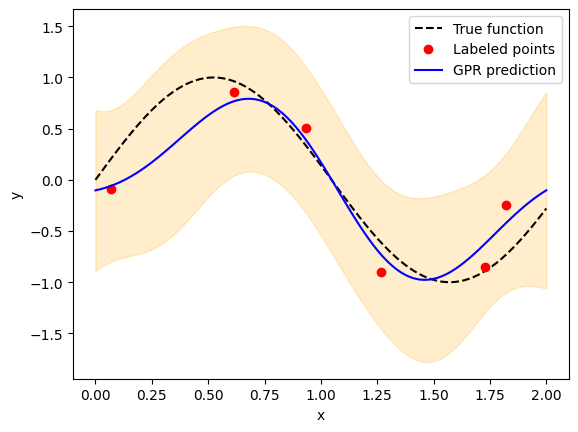

In [17]:
plt.fill_between(X_test.flatten(), y_pred-2*y_std, y_pred+2*y_std, alpha=0.2, color='orange') # plot the variance
plt.plot(X_test, y_test, 'k--', label='True function')
plt.plot(X_labeled, y_labeled, 'ro', label='Labeled points')
plt.plot(X_test, y_pred, 'b-', label='GPR prediction')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

We got worse MSE, and that is normal for the initial iteration, as the newly added region can be very noisy. As we add more points, things will improve.

## Next, put the above into an iteration!

In [18]:
# starting with 5 points
idx = np.random.choice(n_data, 5, replace=False) # choose 5 indices
X_labeled, y_labeled = X[idx], y[idx] # only 5 labeled points

# remove the labeled points from the dataset to create the unlabeled pool
X_unlabeled = np.delete(X, idx, axis=0)
y_unlabeled = np.delete(y, idx, axis=0)

kernel = 1.0*RBF(length_scale=0.3) + WhiteKernel(noise_level=0.1)

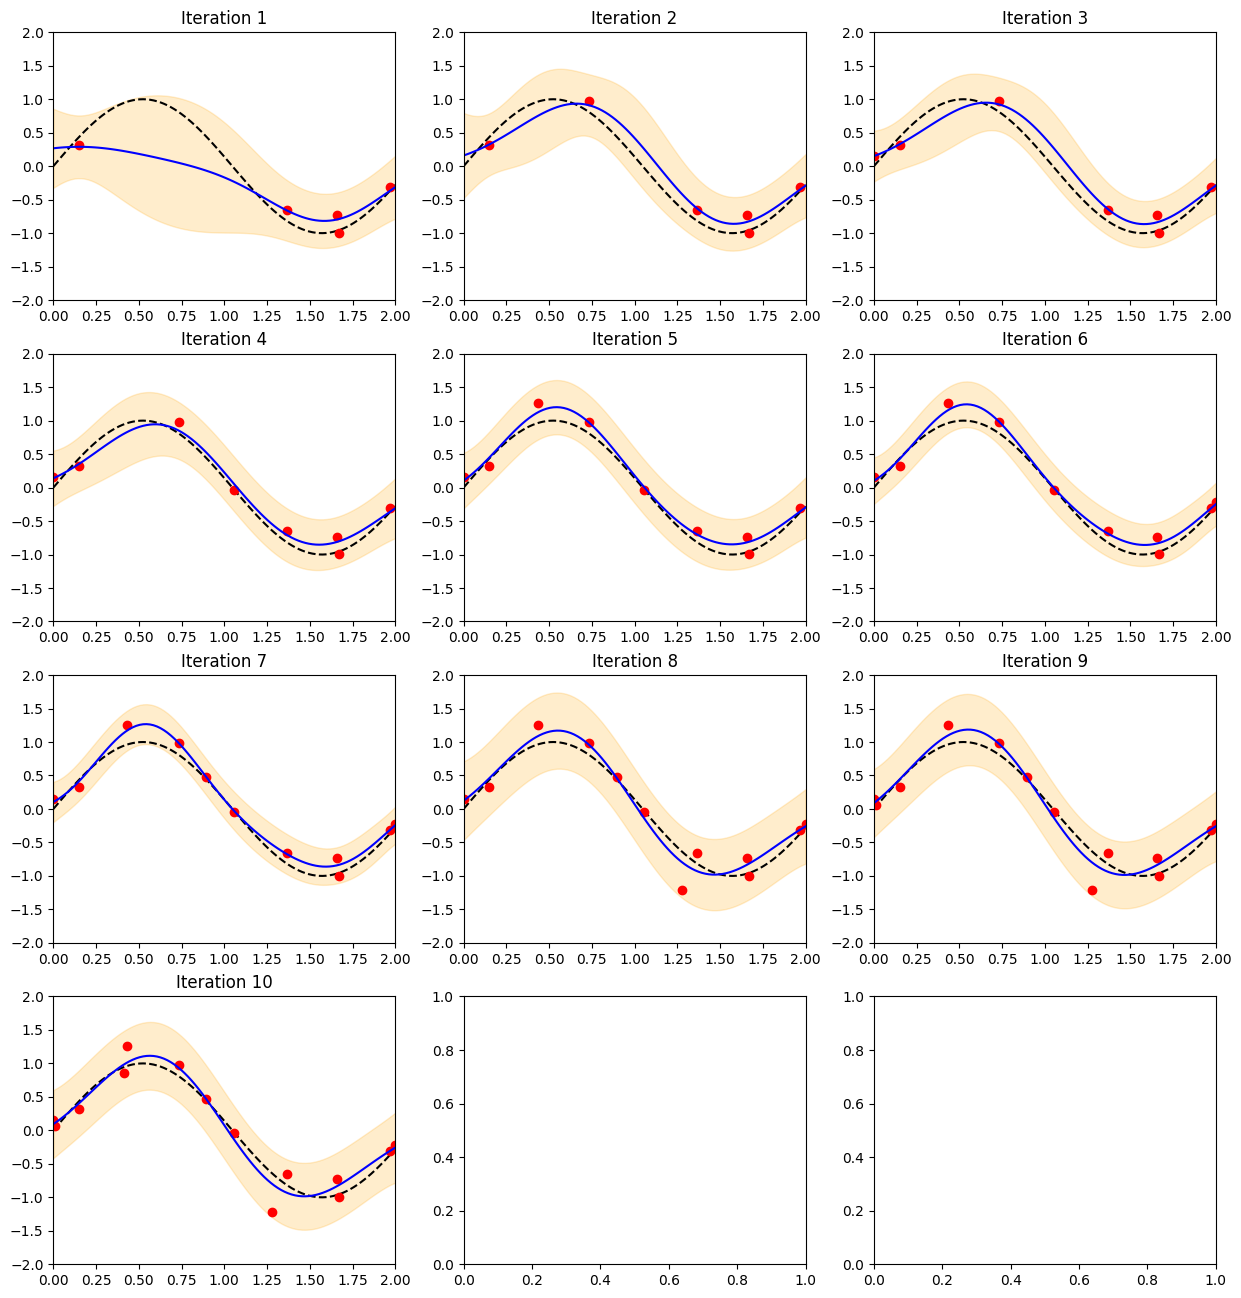

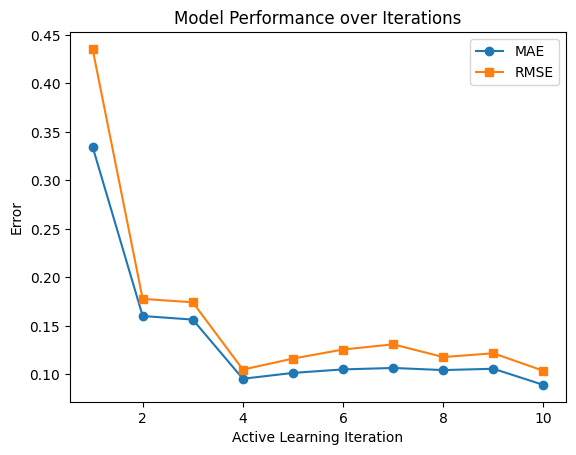

In [19]:
num_iter = 10

# make lists to store training progress
mae_list = []
rmse_list = []


# setting up the plotting
nx_panel = 3
ny_panel = num_iter//nx_panel + int(bool(num_iter%nx_panel))
fig, axes = plt.subplots(ny_panel, nx_panel, figsize=(nx_panel*5, ny_panel*4))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# start the GPR-active learning-GPR-active learning... iteration
for iteration in range(num_iter):
    # Train GPR
    gpr = GaussianProcessRegressor(kernel=kernel, random_state=0)
    gpr.fit(X_labeled, y_labeled)

    # Evaluate on test set
    y_pred, y_std = gpr.predict(X_test, return_std=True)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Plot in the corresponding subplot
    ax = axes[iteration]
    ax.fill_between(X_test.flatten(), y_pred-2*y_std, y_pred+2*y_std, alpha=0.2, color='orange')
    ax.plot(X_test, y_test, 'k--', label='True function')
    ax.plot(X_labeled, y_labeled, 'ro', label='Labeled points')
    ax.plot(X_test, y_pred, 'b-', label='GPR prediction')
    ax.set_title(f'Iteration {iteration+1}')
    ax.set_xlim(0,2)
    ax.set_ylim(-2,2)

    # Uncertainty-based selection
    y_unlabeled_pred, y_unlabeled_std = gpr.predict(X_unlabeled, return_std=True)
    query_idx = np.argmax(y_unlabeled_std)

    # Add new labeled point
    X_new = X_unlabeled[query_idx].reshape(1,-1)
    y_new = y_unlabeled[query_idx].reshape(1,-1)
    X_labeled = np.vstack([X_labeled, X_new])
    y_labeled = np.vstack([y_labeled, y_new])
    X_unlabeled = np.delete(X_unlabeled, query_idx, axis=0)
    y_unlabeled = np.delete(y_unlabeled, query_idx, axis=0)

# Plot the progress
plt.figure()
plt.plot(range(1,len(mae_list)+1), mae_list, 'o-', label='MAE')
plt.plot(range(1,len(rmse_list)+1), rmse_list, 's-', label='RMSE')
plt.xlabel('Active Learning Iteration')
plt.ylabel('Error')
plt.title('Model Performance over Iterations')
plt.legend()
# plt.show()